In [361]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt 

import portfolio
import market_data
import models
import simulation
import risk_measure

# import arch

import importlib

my_modules = [portfolio, market_data, models, simulation, risk_measure]

for module in  my_modules:
    importlib.reload(module)


[*********************100%***********************]  1 of 1 completed


<Axes: xlabel='Date'>

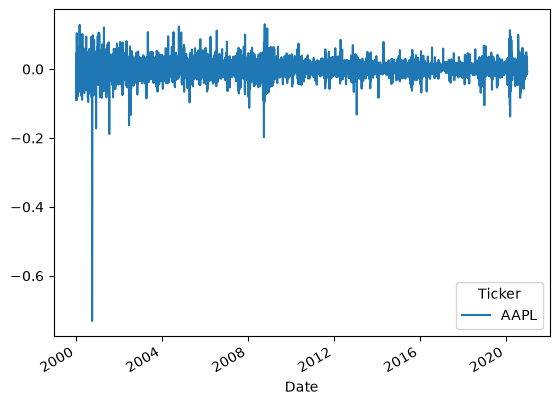

In [362]:
port = portfolio.Portfolio(
    holdings={
        # "MSFT": 2,
        "AAPL": 3
    }
)

data = market_data.MarketData.from_yfinance(
    port.assets,
    "2000-01-01",
    "2021-01-01",
)

risk_factors = port.risk_factors(data)
risk_factors.plot()

In [363]:
ewma = models.univariate_ewma_variance_estimator(
    risk_factors
)

print(port.weights(data))

print(type(ewma.variances))
print(models.univariate_ewma_forecast(risk_factors,ewma))
# risk_factors.plot()
# (2*np.sqrt(ewma.covariances)).plot()
# (-2*np.sqrt(ewma.covariances)).plot()

Ticker      AAPL
Date            
2000-01-03   1.0
2000-01-04   1.0
2000-01-05   1.0
2000-01-06   1.0
2000-01-07   1.0
...          ...
2020-12-24   1.0
2020-12-28   1.0
2020-12-29   1.0
2020-12-30   1.0
2020-12-31   1.0

[5284 rows x 1 columns]
<class 'pandas.core.series.Series'>
2020-12-31    0.000406
Name: AAPL, dtype: float64


In [364]:
garch1_1 = models.fit_garch(risk_factors)

In [365]:

print("GARCH(1,1) model:", "\n", garch1_1.summary(), "\n")

GARCH(1,1) model: 
                        Zero Mean - GARCH Model Results                        
Dep. Variable:                   AAPL   R-squared:                       0.000
Mean Model:                 Zero Mean   Adj. R-squared:                  0.000
Vol Model:                      GARCH   Log-Likelihood:               -11664.7
Distribution:                  Normal   AIC:                           23335.4
Method:            Maximum Likelihood   BIC:                           23355.1
                                        No. Observations:                 5283
Date:                Sat, Sep 19 2026   Df Residuals:                     5283
Time:                        12:12:29   Df Model:                            0
                             Volatility Model                             
                 coef    std err          t      P>|t|    95.0% Conf. Int.
--------------------------------------------------------------------------
omega          0.0914  4.031e-02      2.268 

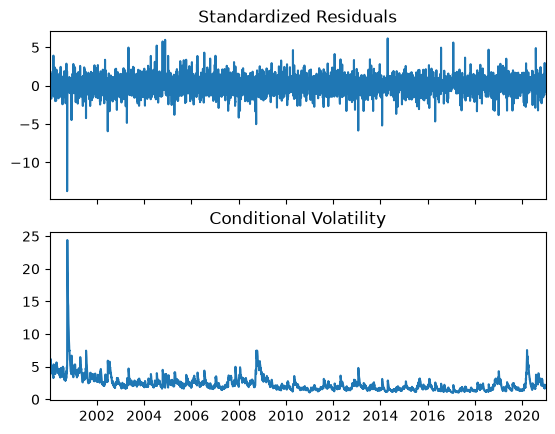

In [366]:
garch1_1.plot()
plt.show()
plt.close()

Date
2000-01-04    0.002767
2000-01-05    0.003293
2000-01-06    0.002953
2000-01-07    0.003504
2000-01-10    0.003347
                ...   
2020-12-24    0.000403
2020-12-28    0.000373
2020-12-29    0.000472
2020-12-30    0.000447
2020-12-31    0.000414
Name: AAPL, Length: 5283, dtype: float64


<Axes: xlabel='Date'>

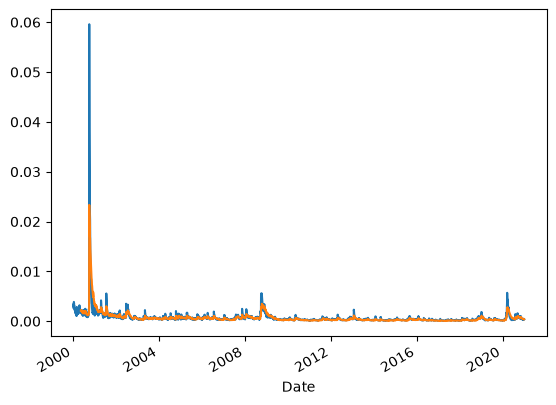

In [367]:
garch1_1_cond_var = (models.garch_conditional_variance(garch1_1).variances)
print(garch1_1_cond_var)
garch1_1_cond_var.plot()
(ewma.variances).plot()

In [368]:
# print(models.garch_forecast(garch1_1))
# print(models.ewma_forecast(risk_factors,ewma))
# ewma.variances
# risk_factors.index[-1]
# type(garch1_1.model.distribution)
# print((risk_factors)["^GSPC"], ewma.variances)
print(risk_factors.squeeze().div(np.sqrt(ewma.variances)))

Date
2000-01-04         NaN
2000-01-05         NaN
2000-01-06         NaN
2000-01-07         NaN
2000-01-10         NaN
                ...   
2020-12-24    0.371551
2020-12-28    1.729516
2020-12-29   -0.634922
2020-12-30   -0.410552
2020-12-31   -0.377002
Name: AAPL, Length: 5283, dtype: float64


In [369]:
import arch
# arch.univariate.Normal().parameter_names()

0.01   -2.326348
0.05   -1.644854
Name: quantile, dtype: float64
                  1%        5%
Date                          
2000-01-04  0.122373  0.086524
2000-01-05  0.133488  0.094383
2000-01-06  0.126426  0.089390
2000-01-07  0.137714  0.097371
2000-01-10  0.134595  0.095166
...              ...       ...
2020-12-24  0.046694  0.033015
2020-12-28  0.044926  0.031765
2020-12-29  0.050535  0.035731
2020-12-30  0.049187  0.034778
2020-12-31  0.047315  0.033455

[5283 rows x 2 columns]


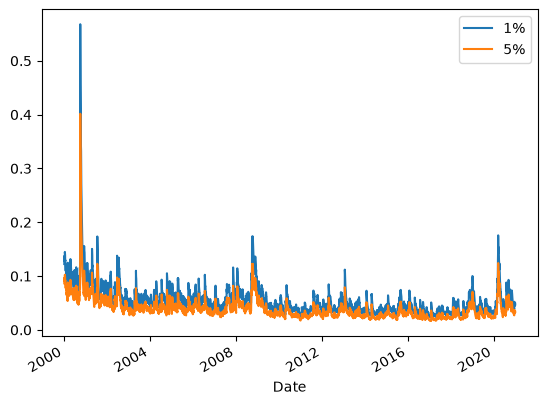

In [370]:
q = simulation.parametric_quantiles("normal",[0.01,0.05])
print(q)

VaR = risk_measure.parametric_value_at_risk(garch1_1_cond_var,q)
print(VaR)
# risk_factors.plot()
VaR.plot()
plt.show()

                  1%        5%
Date                          
2000-01-04  0.140199  0.108505
2000-01-05  0.152932  0.118360
2000-01-06  0.144842  0.112099
2000-01-07  0.157774  0.122108
2000-01-10  0.154201  0.119342
...              ...       ...
2020-12-24  0.053496  0.041402
2020-12-28  0.051470  0.039835
2020-12-29  0.057896  0.044808
2020-12-30  0.056352  0.043613
2020-12-31  0.054208  0.041953

[5283 rows x 2 columns]


<Axes: xlabel='Date'>

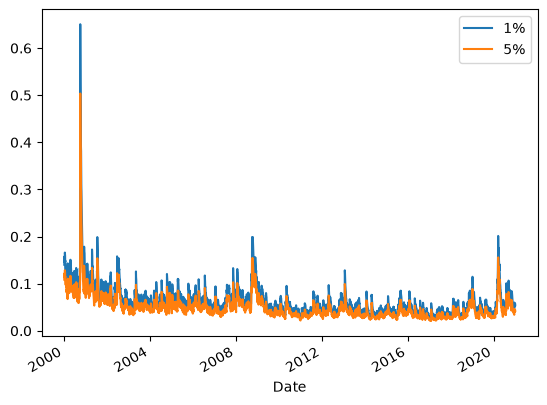

In [371]:
tail_means=simulation.parametric_tail_means("normal",[0.01,0.05])
Es=risk_measure.expected_shortfall(garch1_1_cond_var,tail_means)
print(Es)
Es.plot()


In [372]:
# portBT = portfolio.Portfolio(
#     holdings={
#         "^GSPC": 1,
#     }
# )

# dataBT = market_data.MarketData.from_yfinance(
#     portBT.assets,
#     "2000-01-01",
#     "2020-12-31",
#     # "2000-12-31",
# )

# risk_factorsBT = portBT.risk_factors(dataBT)



# estimation_window_length = 500
# testing_window_length = len(risk_factorsBT) 

# ewmaBT = models.univariate_ewma_variance_estimator(risk_factorsBT)
# q=simulation.parametric_quantiles("normal",[0.01,0.05])

# Var_data_frame = pd.DataFrame()

# var_results = []

# ewmaBT = models.univariate_ewma_variance_estimator(
#     risk_factorsBT
# )

# ewmaBT.variances[0:500]

In [373]:

# for t in range(estimation_window_length, testing_window_length):

#     estimation_first_day = t - estimation_window_length
#     estimation_last_day = t

#     window = risk_factorsBT.iloc[
#         estimation_first_day:estimation_last_day
#     ]



#     variance_t = models.ewma_forecast(
#         window,
#         ewmaBT,
#     )

#     ewmaBT_var = risk_measure.parametric_value_at_risk(
#         variance_t,
#         q,
#     )

#     target_date = risk_factorsBT.index[t]x

#     ewmaBT_var.index = [target_date]

#     var_results.append(ewmaBT_var)

# Var_data_frame = pd.concat(var_results)

# print(Var_data_frame)

# Var_data_frame.plot()

[*********************100%***********************]  1 of 1 completed


                  1%        5%
2002-01-03  0.023688  0.016749
2002-01-04  0.023595  0.016683
2002-01-07  0.023298  0.016473
2002-01-08  0.023028  0.016282
2002-01-09  0.022624  0.015997
...              ...       ...
2020-12-23  0.021784  0.015403
2020-12-24  0.021347  0.015093
2020-12-28  0.020980  0.014834
2020-12-29  0.020949  0.014812
2020-12-30  0.020552  0.014532

[4782 rows x 2 columns]


<Axes: >

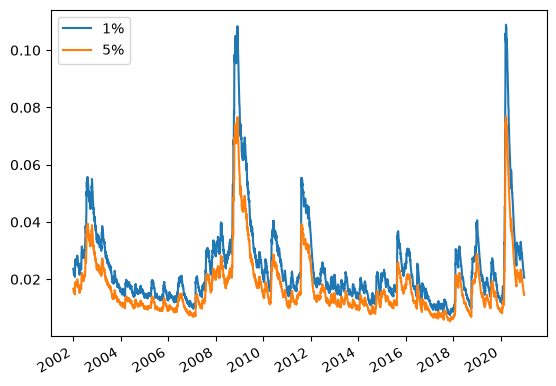

In [ ]:
portBT = portfolio.Portfolio(
    holdings={
        "^GSPC": 1,
    }
)

dataBT = market_data.MarketData.from_yfinance(
    portBT.assets,
    "2000-01-01",
    "2020-12-31",
)

risk_factorsBT = portBT.risk_factors(dataBT)


# --------------------------------------------------------
# EWMA variance path
# --------------------------------------------------------

ewma_result = models.univariate_ewma_variance_estimator(
    risk_factorsBT
)

# Normal quantiles do not change through time
q = simulation.parametric_quantiles(
    "normal",
    [0.01, 0.05],
)


# --------------------------------------------------------
# Backtest
# --------------------------------------------------------

backtest_start = 500

var_ewma_results = []
var_garch11_results = []

estimation_window_length = 500 
testing_window_length = len(risk_factorsBT)


for t in range(estimation_window_length, testing_window_length):

    estimation_first_day = t - estimation_window_length
    estimation_last_day = t

    window = risk_factorsBT.iloc[
        estimation_first_day:estimation_last_day
    ]

    # ----------------------------------
    # EWMA
    # ----------------------------------

    # Forecast sigma^2_(t | t-1)
    variance_ewma_t = models.univariate_ewma_forecast(
        window,
        ewma_result,
    )

    # VaR forecast for t
    var_ewma_t = risk_measure.parametric_value_at_risk(
        variance_ewma_t,
        q,
    )

    # ewma_forecast is indexed by forecast origin t-1,
    # but for backtesting we want the target date t
    target_date = risk_factorsBT.index[t]

    var_ewma_t.index = [target_date]

    var_ewma_results.append(var_ewma_t)


    # ----------------------------------
    # GARCH(1,1) with normal innovations
    # ----------------------------------

    garch11_fit = models.fit_garch(window,1,1,0,"Normal")

    variance_garch11_t = models.garch_forecast(garch11_fit)

    var_garch11_t = risk_measure.parametric_value_at_risk(variance_garch11_t,q)

    var_garch11_t.index = [target_date]
    
    var_garch11_results.append(var_garch11_t)


Var_ewma_data_frame = pd.concat(var_ewma_results)
Var_garch11_data_frame = pd.concat(var_garch11_results)


print(Var_ewma_data_frame)
Var_ewma_data_frame.plot()

print(Var_garch11_data_frame)
Var_garch11_data_frame.plot()